# Experiment V1: YOLOv8 Baseline for Object Detection

**Student ID:** 25509225  
**Experiment:** V1 - YOLOv8 Baseline (Standard Model)  
**Model:** YOLOv8m (no customization)

---

## Overview

This experiment trains a standard YOLOv8m model on the dog emotion detection dataset without any architectural modifications. This serves as the baseline for comparison with customized models (V2: Deeper Backbone, V3: Shallower Backbone).

## Cell 1: Load Modules

In [2]:
# Load shared modules from YOLOv8_modules.ipynb
%run ./YOLOv8_modules.ipynb

print("✓ All modules loaded successfully")

✓ ultralytics already installed

Using device: cuda
GPU: Tesla T4
Memory: 14.6 GB

Package Versions:
  PyTorch: 2.8.0
  Ultralytics: 8.4.50
  OpenCV: 4.13.0
  NumPy: 2.4.4
✓ YOLOv8Detector defined
✓ Model configurations defined
✓ YOLOv8Trainer defined
✓ Training configurations defined
✓ DetectionEvaluator defined

✓ All YOLOv8 modules loaded successfully!
✓ All modules loaded successfully


## Cell 2: Configuration

In [3]:
# ============================================================================
# Experiment V1: YOLOv8 Baseline Configuration
# ============================================================================

# === Model Configuration ===
YOLOV8_V1_MODEL_CONFIG = {
    'backbone': 'm',
    'input_size': 640,
    'confidence_threshold': 0.5,
    'nms_iou_threshold': 0.45,
    'pretrained': True,
    'customize_type': None  # Baseline - no customization
}

# === Training Configuration ===
TRAINING_CONFIG_V1 = {
    'learning_rate': 0.001,
    'batch_size': 12,        # Reduced from 16 to avoid OOM on T4 (14.6GB)
    'epochs': 300,
    'optimizer': 'adam',
    'weight_decay': 1e-4,
    'use_amp': True,         # Mixed precision (already enabled)
    'patience': 50,          # Early stopping patience
    'cos_lr': True,         # No cosine LR schedule
    'close_mosaic': 10        # Keep mosaic augmentation throughout
}

# === Experiment Settings ===
STUDENT_ID = "25509225"
DATASET_CONFIG = f"/home/sagemaker-user/CNN_A2/data/{STUDENT_ID}/Object_Detection/yolo/data.yaml"
USE_PRETRAINED = True

# Output directory (simplified, no timestamp subdirectory)
output_dir = Path('/home/sagemaker-user/CNN_A2/notebooks/detection_YOLOv8/outputs/detection_yolov8_baseline')
output_dir.mkdir(parents=True, exist_ok=True)

# Print experiment info
print("=" * 80)
print("EXPERIMENT V1: YOLOv8 Baseline")
print("=" * 80)
print(f"\nExperiment Settings:")
print(f"  Student ID: {STUDENT_ID}")
print(f"  Dataset Config: {DATASET_CONFIG}")
print(f"  Output Directory: {output_dir}")
print(f"\nModel Configuration:")
print(f"  Backbone: YOLOv8{YOLOV8_V1_MODEL_CONFIG['backbone']}")
print(f"  Input Size: {YOLOV8_V1_MODEL_CONFIG['input_size']}")
print(f"  Pretrained: {USE_PRETRAINED}")
print(f"  Customization: None (Baseline)")
print(f"\nTraining Configuration:")
print(f"  Learning Rate: {TRAINING_CONFIG_V1['learning_rate']}")
print(f"  Batch Size: {TRAINING_CONFIG_V1['batch_size']}")
print(f"  Epochs: {TRAINING_CONFIG_V1['epochs']}")
print(f"  Optimizer: {TRAINING_CONFIG_V1['optimizer']}")
print(f"  Weight Decay: {TRAINING_CONFIG_V1['weight_decay']}")
print(f"  Mixed Precision: {TRAINING_CONFIG_V1['use_amp']}")
print(f"  Early Stopping: {TRAINING_CONFIG_V1['patience']} epochs")
print(f"  Cosine LR: {TRAINING_CONFIG_V1['cos_lr']}")
print(f"  Close Mosaic: {TRAINING_CONFIG_V1['close_mosaic']} epochs")

EXPERIMENT V1: YOLOv8 Baseline

Experiment Settings:
  Student ID: 25509225
  Dataset Config: /home/sagemaker-user/CNN_A2/data/25509225/Object_Detection/yolo/data.yaml
  Output Directory: /home/sagemaker-user/CNN_A2/notebooks/detection_YOLOv8/outputs/detection_yolov8_baseline

Model Configuration:
  Backbone: YOLOv8m
  Input Size: 640
  Pretrained: True
  Customization: None (Baseline)

Training Configuration:
  Learning Rate: 0.001
  Batch Size: 12
  Epochs: 300
  Optimizer: adam
  Weight Decay: 0.0001
  Mixed Precision: True
  Early Stopping: 50 epochs
  Cosine LR: True
  Close Mosaic: 10 epochs


## Cell 3: Step 1 - Load Dataset Configuration

In [4]:
# ============================================================================
# Step 1: Load Dataset Configuration
# ============================================================================

print("\n[1/5] Loading dataset configuration...")
print("=" * 80)

dataset_config_path = Path(DATASET_CONFIG)

if not dataset_config_path.exists():
    print(f"Error: Dataset config not found: {dataset_config_path}")
    print("Please check the DATASET_CONFIG path in Cell 2")
    raise FileNotFoundError(f"Dataset config not found: {dataset_config_path}")

with open(dataset_config_path, 'r') as f:
    dataset_config = yaml.safe_load(f)

print(f"Dataset config: {dataset_config_path}")
print(f"Number of classes: {dataset_config['nc']}")
print(f"Class names: {dataset_config['names']}")
print(f"\nPaths:")
print(f"  Train: {dataset_config.get('train', 'N/A')}")
print(f"  Val: {dataset_config.get('val', 'N/A')}")
print(f"  Test: {dataset_config.get('test', 'N/A')}")
print("\n✓ Dataset configuration loaded successfully")


[1/5] Loading dataset configuration...
Dataset config: /home/sagemaker-user/CNN_A2/data/25509225/Object_Detection/yolo/data.yaml
Number of classes: 5
Class names: ['Cell', 'Cell-Multi', 'No-Anomaly', 'Shadowing', 'Unclassified']

Paths:
  Train: ../train/images
  Val: ../valid/images
  Test: ../test/images

✓ Dataset configuration loaded successfully


## Cell 4: Step 2 - Initialize Model

In [5]:
# ============================================================================
# Step 2: Initialize YOLOv8 Model
# ============================================================================

print("\n[2/5] Initializing YOLOv8 model...")
print("=" * 80)

# Update model config with the pretrained setting
model_config = YOLOV8_V1_MODEL_CONFIG.copy()
model_config['pretrained'] = USE_PRETRAINED

# Create model
model = YOLOv8Detector(**model_config)

print(f"\nModel Information:")
print(f"  Model: Standard YOLOv8{model_config['backbone']}")
print(f"  Input Size: {model_config['input_size']}")
print(f"  Pretrained: {USE_PRETRAINED}")
print(f"  Customization: None (Baseline)")
print(f"  Confidence Threshold: {model_config['confidence_threshold']}")
print(f"  NMS IoU Threshold: {model_config['nms_iou_threshold']}")

# Calculate approximate parameters
total_params = sum(p.numel() for p in model.model.parameters())
print(f"\n  Total Parameters: ~{total_params/1e6:.1f}M")
print("\n✓ Model initialized successfully")


[2/5] Initializing YOLOv8 model...

Model Information:
  Model: Standard YOLOv8m
  Input Size: 640
  Pretrained: True
  Customization: None (Baseline)
  Confidence Threshold: 0.5
  NMS IoU Threshold: 0.45

  Total Parameters: ~25.9M

✓ Model initialized successfully


## Cell 5: Step 3 - Train Model

In [6]:
# ============================================================================
# Step 3: Train Model
# ============================================================================

print("\n[3/5] Training model...")
print("=" * 80)

# Check for existing checkpoint
checkpoint_path = output_dir / 'train' / 'weights' / 'last.pt'
resume_training = False

if checkpoint_path.exists():
    print(f"\n✓ Found existing checkpoint: {checkpoint_path}")
    print("  Resuming training from last checkpoint...")

    try:
        import torch
        from ultralytics import YOLO

        checkpoint = torch.load(
            checkpoint_path,
            map_location='cpu',
            weights_only=False
        )

        last_epoch = checkpoint.get('epoch', 0)

        print(f"  Last completed epoch: {last_epoch + 1}")
        print(f"  Remaining epochs: {TRAINING_CONFIG_V1['epochs'] - (last_epoch + 1)}")

        # Load checkpoint model
        model.model = YOLO(str(checkpoint_path))

        resume_training = True

    except Exception as e:
        print(f"  Warning: Could not load checkpoint: {e}")
        print("  Starting fresh training instead...")
else:
    print(f"\n  No checkpoint found. Starting fresh training...")

# Initialize trainer
trainer = YOLOv8Trainer(**TRAINING_CONFIG_V1)

# Train model with resume option
training_results = trainer.train(
    model=model,
    train_data=DATASET_CONFIG,
    val_data=DATASET_CONFIG,
    output_dir=str(output_dir),
    resume=resume_training
)

# Print training summary
print("\n" + "=" * 80)
print("TRAINING COMPLETED")
print("=" * 80)
print(f"\nTraining Results:")
print(f"  Best mAP@0.5: {training_results.box.map50:.4f}")
print(f"  Best mAP@0.5:0.95: {training_results.box.map:.4f}")
print(f"  Output Directory: {output_dir}")
print("\n✓ Model training completed successfully")


[3/5] Training model...

✓ Found existing checkpoint: /home/sagemaker-user/CNN_A2/notebooks/detection_YOLOv8/outputs/detection_yolov8_baseline/train/weights/last.pt
  Resuming training from last checkpoint...
  Last completed epoch: 286
  Remaining epochs: 14

Training Configuration:
  Learning Rate: 0.001
  Batch Size: 12
  Epochs: 300
  Optimizer: adam
  Weight Decay: 0.0001
  Mixed Precision: True
  Early Stopping Patience: 50
  Cosine LR: True
  Close Mosaic: 10 epochs before end

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.8.0 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/sagemaker-user/CNN_A2/data/25509225/Object_Detection/yolo/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=Fals

2026/05/14 13:01:47 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.


MLflow: logging run_id(adfca87f1fc5487095ae83c973bdb92f) to /home/sagemaker-user/CNN_A3/runs/mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri /home/sagemaker-user/CNN_A3/runs/mlflow'
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to /home/sagemaker-user/CNN_A2/notebooks/detection_YOLOv8/outputs/detection_yolov8_baseline/train
Starting training for 300 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    287/300      10.1G     0.4912     0.2475     0.7974        492        640: 100% ━━━━━━━━━━━━ 98/98 2.5it/s 39.4s0.4ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 3.2it/s 3.4s0.3s
                   all        250      14743      0.974      0.962      0.988      0.848

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    288/300      7.48G 

In [7]:
# ============================================================================
# Step 4: Evaluate on Test Set
# ============================================================================

print("\n[4/5] Evaluating on test set...")
print("=" * 80)

# Initialize evaluator
evaluator = DetectionEvaluator()

# Evaluate model
metrics = evaluator.evaluate_yolov8(
    model=model,
    test_dataset=DATASET_CONFIG,
    output_dir=str(output_dir)
)

print("\n" + "=" * 80)
print("EVALUATION COMPLETED")
print("=" * 80)
print(f"\nTest Set Metrics:")
print(f"  mAP@0.5: {metrics['map50']:.4f}")
print(f"  mAP@0.5:0.95: {metrics['map50_95']:.4f}")
print(f"  Precision: {metrics['precision']:.4f}")
print(f"  Recall: {metrics['recall']:.4f}")
print(f"  F1-Score: {metrics['f1']:.4f}")
print("\n✓ Model evaluation completed successfully")


[4/5] Evaluating on test set...
MODEL EVALUATION
WARNING ⚠️ 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.8.0 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,655 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 62.1±12.9 MB/s, size: 64.2 KB)
val: Scanning /home/sagemaker-user/CNN_A2/data/25509225/Object_Detection/yolo/test/labels.cache... 250 images, 79 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 250/250 95.3Mit/s 0.0s
val: /home/sagemaker-user/CNN_A2/data/25509225/Object_Detection/yolo/test/images/101422.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 1.9it/s 8.3s0.4s
                   all        250      14860      0.982      0.972      0.989      0.862
                  Cell        126        819       0.97       0.96      0.984      0.862
            Cell-Multi       


=== Detection Results Comparison ===
Found 3 comparison pairs, displaying Batch 0:
  val_batch0_labels.jpg vs val_batch0_pred.jpg


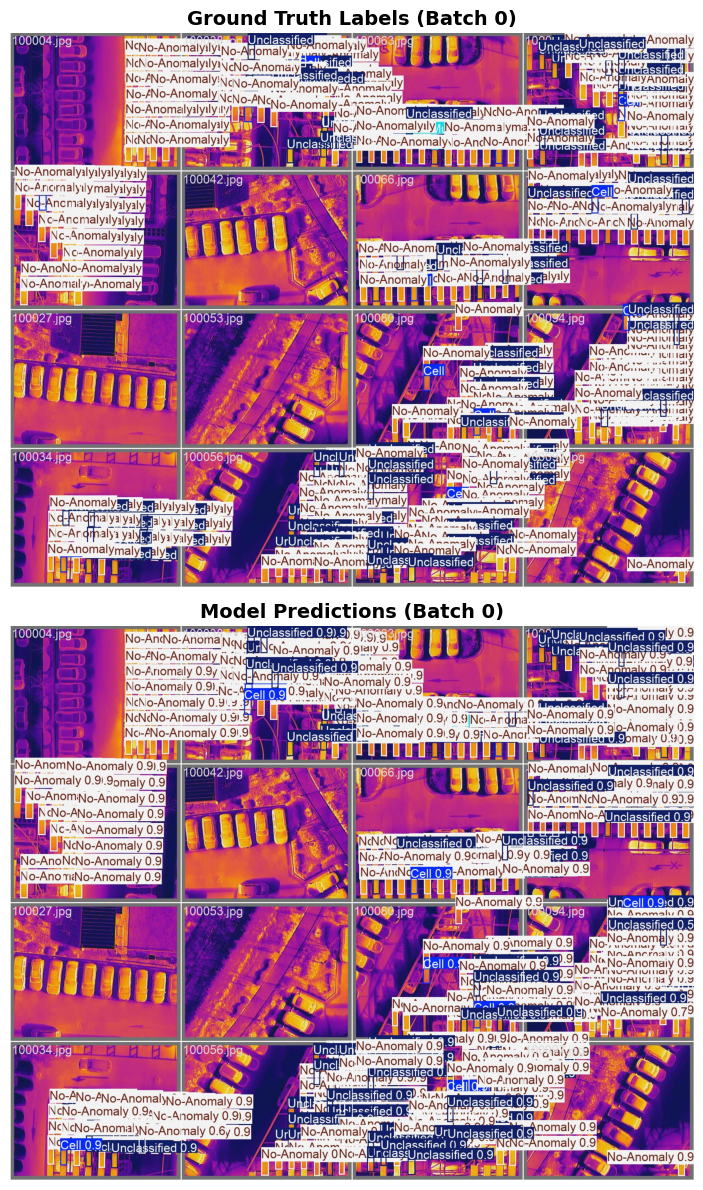


✓ Detection comparison displayed
Left column: Ground truth labels
Right column: Model predictions


In [8]:
# ============================================================================
# Visualization 1: Detection Results Comparison (Labels vs Predictions)
# ============================================================================

print("\n=== Detection Results Comparison ===")
print("=" * 80)

# Display comparison images from evaluation results (no need to re-run inference)
fig = evaluator.plot_detection_comparison(output_dir=str(output_dir))
if fig is not None:
    print("\n✓ Detection comparison displayed")
    print("Left column: Ground truth labels")
    print("Right column: Model predictions")
else:
    print("Warning: Could not generate detection comparison")
    print("This may be because evaluation images were not saved.")


=== Training Loss Curves ===
✓ Loaded training results from /home/sagemaker-user/CNN_A2/notebooks/detection_YOLOv8/outputs/detection_yolov8_baseline/train/results.csv
  Shape: (300, 15)
  Columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


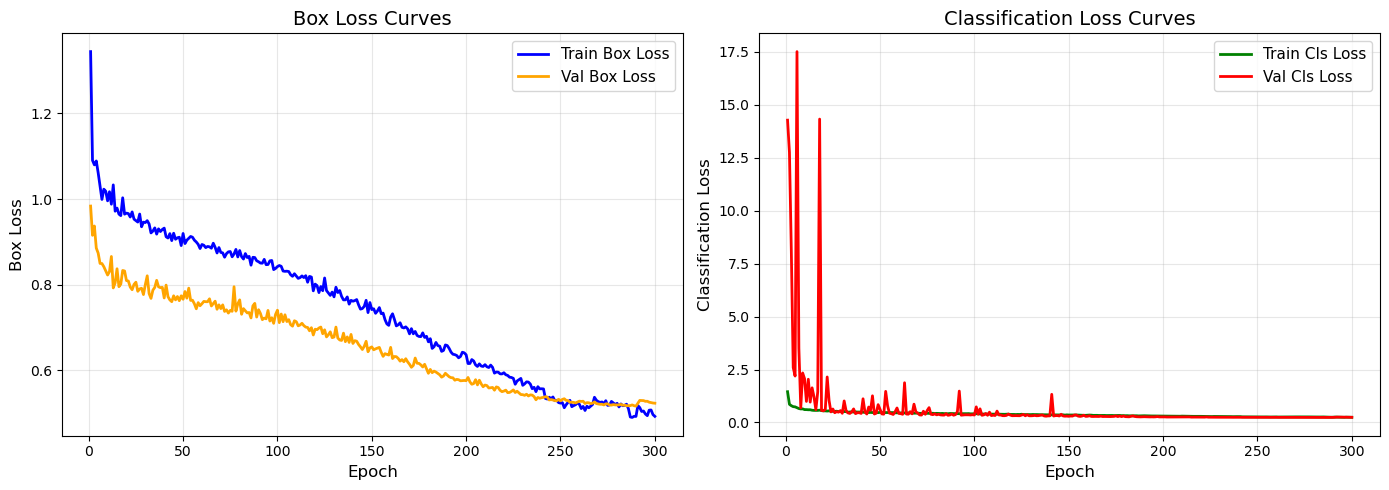


✓ Training loss curves displayed


In [9]:
# ============================================================================
# Visualization 2: Training Loss Curves (Box Loss + Classification Loss)
# ============================================================================

print("\n=== Training Loss Curves ===")
print("=" * 80)

# Store training output path for visualization
train_output_dir = output_dir

# Plot training loss curves
fig = evaluator.plot_training_losses(str(train_output_dir))
if fig is not None:
    plt.show()
    print("\n✓ Training loss curves displayed")
else:
    print("Warning: Could not generate training loss curves")
    print("This may be because training results.csv is not available yet.")
    print("Try running the training cell (Cell 5) first if you haven't already.")


=== Validation mAP Curves ===
✓ Loaded training results from /home/sagemaker-user/CNN_A2/notebooks/detection_YOLOv8/outputs/detection_yolov8_baseline/train/results.csv
  Shape: (300, 15)
  Columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


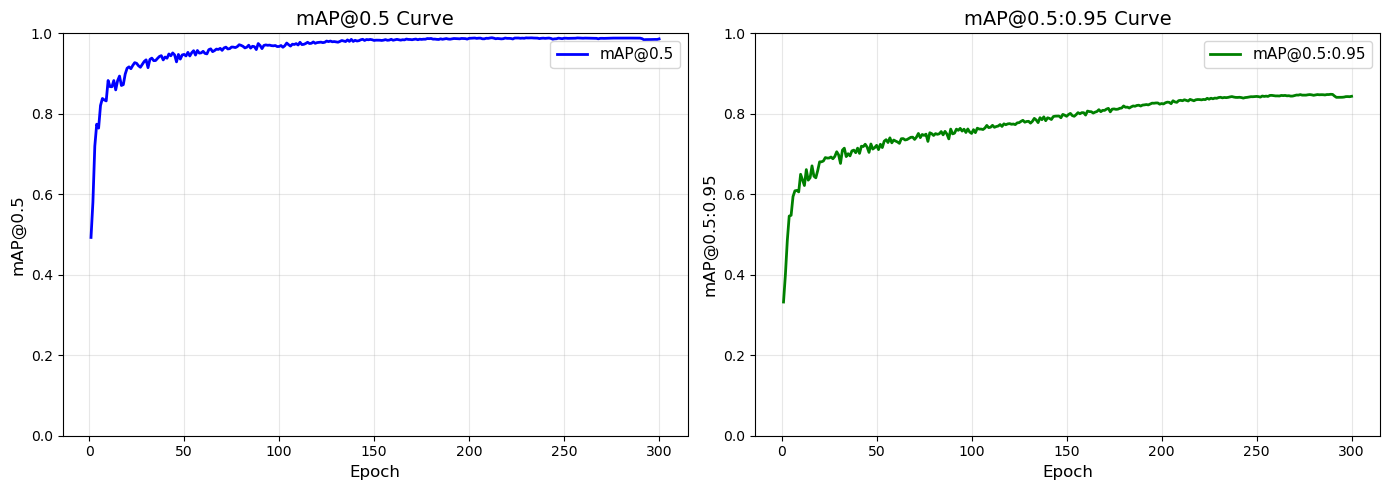


✓ Validation mAP curves displayed


In [10]:
# ============================================================================
# Visualization 3: Validation mAP Curves (mAP@0.5 + mAP@0.5:0.95)
# ============================================================================

print("\n=== Validation mAP Curves ===")
print("=" * 80)

# Plot validation mAP curves
fig = evaluator.plot_validation_mAP(str(train_output_dir))
if fig is not None:
    plt.show()
    print("\n✓ Validation mAP curves displayed")
else:
    print("Warning: Could not generate validation mAP curves")
    print("This may be because training results.csv is not available yet.")
    print("Try running the training cell (Cell 5) first if you haven't already.")


=== Confusion Matrices ===


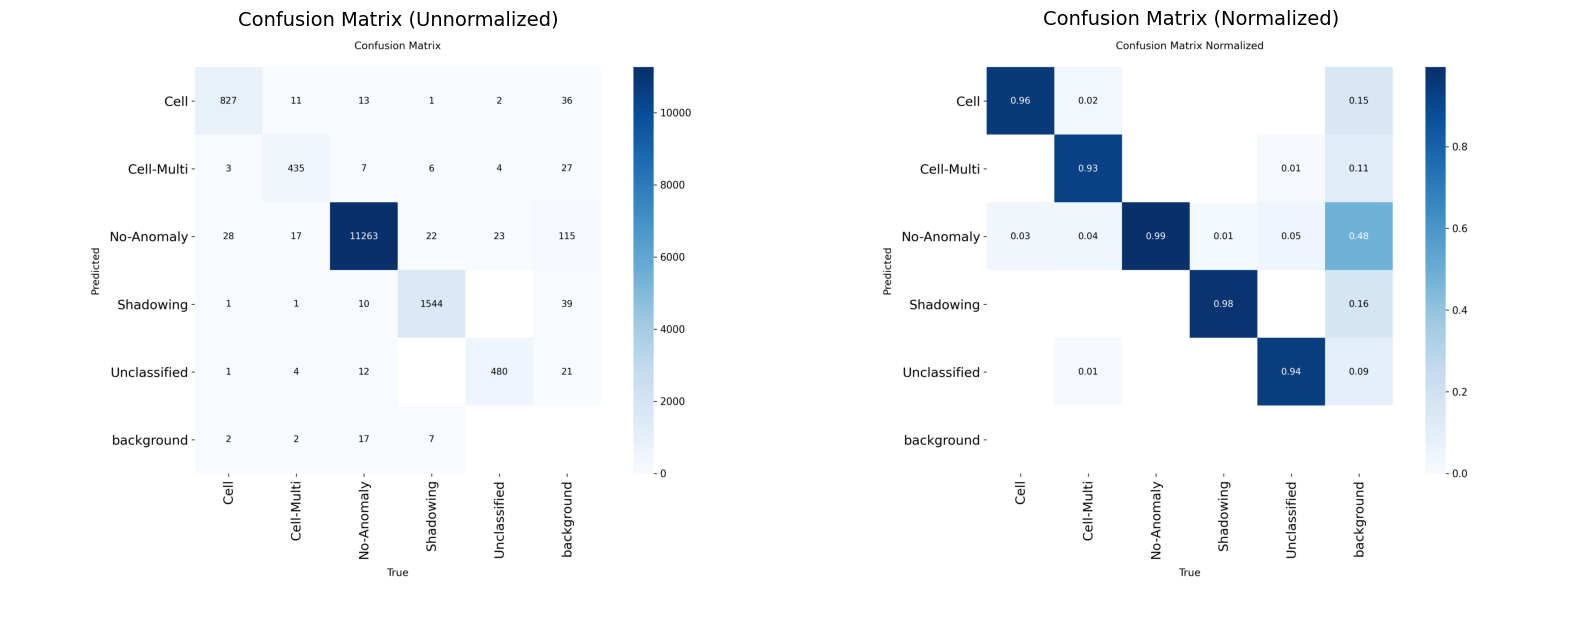


✓ Confusion matrices displayed


In [11]:
# ============================================================================
# Visualization 4: Confusion Matrices (Unnormalized & Normalized)
# ============================================================================

print("\n=== Confusion Matrices ===")
print("=" * 80)

# Plot both confusion matrices side-by-side
fig = evaluator.plot_confusion_matrix(output_dir=str(train_output_dir))
if fig is not None:
    print("\n✓ Confusion matrices displayed")
else:
    print("Warning: Could not generate confusion matrices")
    print("This may be because the model training did not complete successfully.")


=== Precision-Recall Curves ===


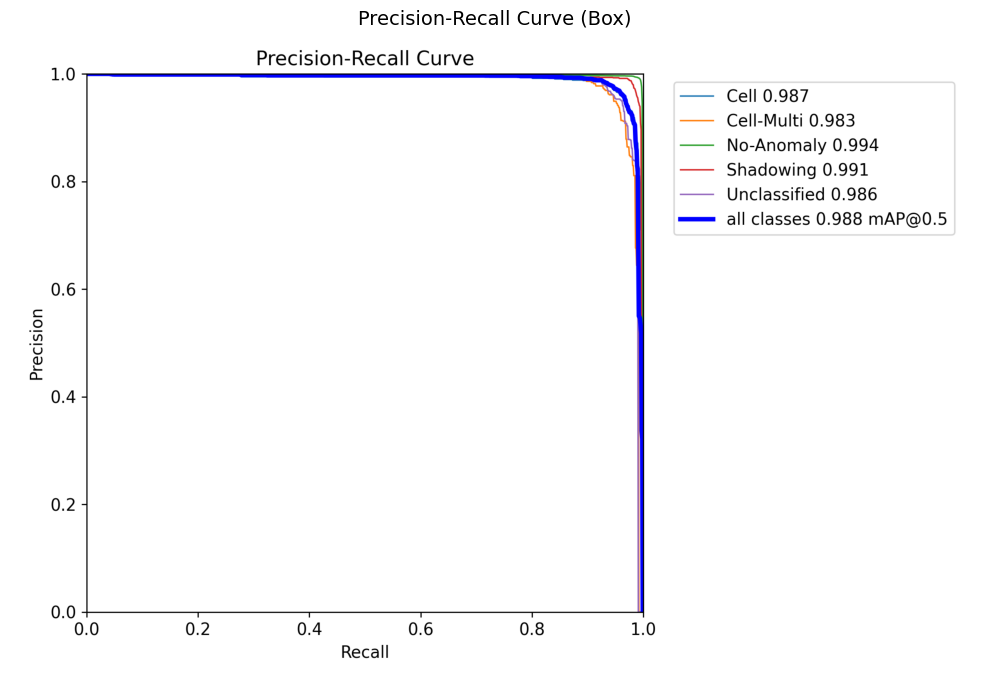


✓ PR curves displayed


<Figure size 640x480 with 0 Axes>

In [12]:
# ============================================================================
# Visualization 5: Precision-Recall Curves
# ============================================================================

print("\n=== Precision-Recall Curves ===")
print("=" * 80)

# Plot PR curves from training results (only BoxPR_curve.png)
fig = evaluator.plot_pr_curves_from_results(str(train_output_dir))
if fig is not None:
    print("\n✓ PR curves displayed")
else:
    print("Warning: Could not generate PR curves")
    print("This may be because BoxPR_curve.png was not generated during training.")

In [13]:
# ============================================================================
# Analysis: Model Characteristics and Performance
# ============================================================================

print("\n" + "=" * 80)
print("MODEL ANALYSIS")
print("=" * 80)

# Model characteristics
total_params = sum(p.numel() for p in model.model.parameters())

print(f"\nModel Characteristics:")
print(f"  Backbone: YOLOv8{model_config['backbone']}")
print(f"  Input Size: {model_config['input_size']}")
print(f"  Total Parameters: ~{total_params/1e6:.1f}M")
print(f"  Customization: Baseline (no modifications)")
print(f"  Pretrained Weights: {USE_PRETRAINED}")

print(f"\nPerformance Summary:")
print(f"  Best mAP@0.5: {training_results.box.map50:.4f}")
print(f"  Best mAP@0.5:0.95: {training_results.box.map:.4f}")
print(f"  Test mAP@0.5: {metrics['map50']:.4f}")
print(f"  Test mAP@0.5:0.95: {metrics['map50_95']:.4f}")
print(f"  Test Precision: {metrics['precision']:.4f}")
print(f"  Test Recall: {metrics['recall']:.4f}")
print(f"  Test F1-Score: {metrics['f1']:.4f}")

print("\n" + "=" * 80)
print("BASELINE MODEL ANALYSIS")
print("=" * 80)
print("\nThis is the baseline model with no architectural modifications.")
print("It will be compared with:")
print("  - V2: YOLOv8m with Deeper Backbone (added convolutional layers)")
print("  - V3: YOLOv8m with Shallower Backbone (reduced convolutional layers)")
print("\n✓ Analysis completed")


MODEL ANALYSIS

Model Characteristics:
  Backbone: YOLOv8m
  Input Size: 640
  Total Parameters: ~25.8M
  Customization: Baseline (no modifications)
  Pretrained Weights: True

Performance Summary:
  Best mAP@0.5: 0.9882
  Best mAP@0.5:0.95: 0.8479
  Test mAP@0.5: 0.9892
  Test mAP@0.5:0.95: 0.8620
  Test Precision: 0.9819
  Test Recall: 0.9717
  Test F1-Score: 0.9767

BASELINE MODEL ANALYSIS

This is the baseline model with no architectural modifications.
It will be compared with:
  - V2: YOLOv8m with Deeper Backbone (added convolutional layers)
  - V3: YOLOv8m with Shallower Backbone (reduced convolutional layers)

✓ Analysis completed



=== Training Results Summary ===


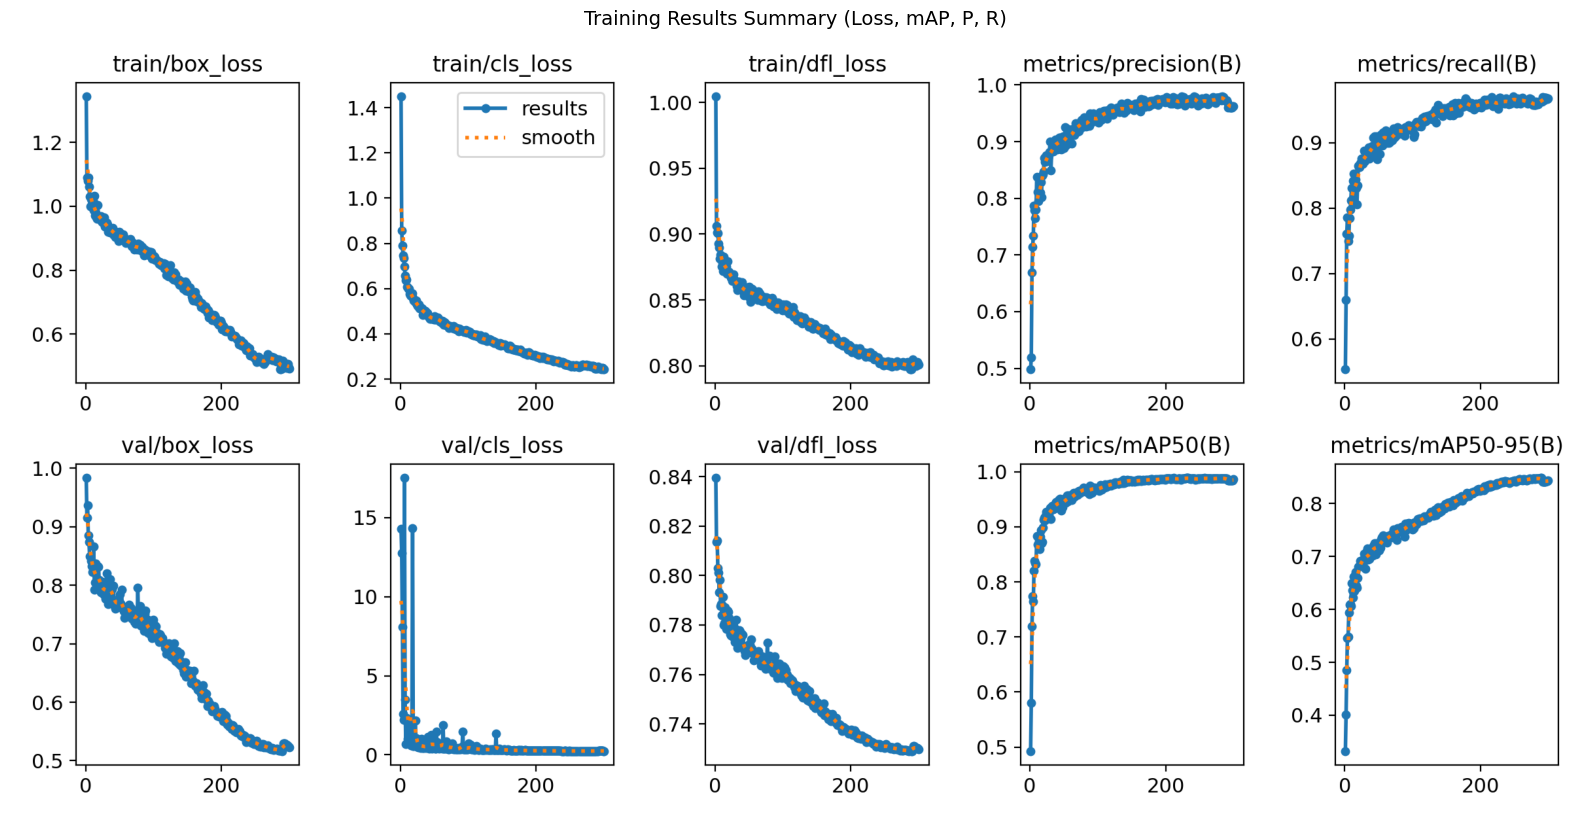


✓ Training results summary displayed
This figure includes:
  - Box Loss and Classification Loss curves
  - mAP@0.5 and mAP@0.5:0.95 curves
  - Precision and Recall curves


<Figure size 640x480 with 0 Axes>

In [14]:
# ============================================================================
# Visualization 6: Training Results Summary (Comprehensive)
# ============================================================================

print("\n=== Training Results Summary ===")
print("=" * 80)

# Plot comprehensive training results (results.png with all metrics)
fig = evaluator.plot_training_results_summary(str(train_output_dir))
if fig is not None:
    print("\n✓ Training results summary displayed")
    print("This figure includes:")
    print("  - Box Loss and Classification Loss curves")
    print("  - mAP@0.5 and mAP@0.5:0.95 curves")
    print("  - Precision and Recall curves")
else:
    print("Warning: Could not generate training results summary")
    print("This may be because results.png was not generated during training.")

In [15]:
# ============================================================================
# Final Summary
# ============================================================================

print("\n" + "=" * 80)
print("EXPERIMENT COMPLETED")
print("=" * 80)

print(f"\nExperiment: V1 - YOLOv8 Baseline")
print(f"Model: YOLOv8{model_config['backbone']} (Standard)")
print(f"Pretrained: {USE_PRETRAINED}")
print(f"Customization: None (Baseline)")

print(f"\n" + "-" * 80)
print(f"Training Performance:")
print(f"  Best mAP@0.5: {training_results.box.map50:.4f}")
print(f"  Best mAP@0.5:0.95: {training_results.box.map:.4f}")

print(f"\n" + "-" * 80)
print(f"Test Set Performance:")
print(f"  mAP@0.5: {metrics['map50']:.4f}")
print(f"  mAP@0.5:0.95: {metrics['map50_95']:.4f}")
print(f"  Precision: {metrics['precision']:.4f}")
print(f"  Recall: {metrics['recall']:.4f}")
print(f"  F1-Score: {metrics['f1']:.4f}")

print(f"\n" + "-" * 80)
print(f"Output Directory: {output_dir}")
print("\n" + "=" * 80)
print("✓ All experiments completed successfully")
print("=" * 80)


EXPERIMENT COMPLETED

Experiment: V1 - YOLOv8 Baseline
Model: YOLOv8m (Standard)
Pretrained: True
Customization: None (Baseline)

--------------------------------------------------------------------------------
Training Performance:
  Best mAP@0.5: 0.9882
  Best mAP@0.5:0.95: 0.8479

--------------------------------------------------------------------------------
Test Set Performance:
  mAP@0.5: 0.9892
  mAP@0.5:0.95: 0.8620
  Precision: 0.9819
  Recall: 0.9717
  F1-Score: 0.9767

--------------------------------------------------------------------------------
Output Directory: /home/sagemaker-user/CNN_A2/notebooks/detection_YOLOv8/outputs/detection_yolov8_baseline

✓ All experiments completed successfully
